# Previsão de Ações em Estufa Semi-Hidropônica de Morango

**Projeto de Machine Learning — Classificação Multiclasse**

Este notebook tem como objetivo desenvolver um modelo de classificação capaz de
prever qual **ação** deve ser tomada em uma estufa semi-hidropônica de morango,
com base em variáveis climáticas e de solo/nutrientes coletadas diariamente.

**Variável alvo:** `acao_nome`, com 4 classes possíveis:

| Classe | Significado |
|---|---|
| `Ideal` | Nenhuma ação necessária, condições ótimas |
| `Proteger` | Proteger a cultura (ex: calor/umidade extremos) |
| `Irrigar` | Necessidade de irrigação |
| `Travar Irrigação` | Bloquear irrigação (ex: solo/ar já saturados) |

O dataset é **desbalanceado**, portanto todas as decisões de modelagem e
avaliação ao longo do notebook levarão isso em consideração.


## 1. Importação das Bibliotecas

Utilizamos um conjunto enxuto de bibliotecas: `pandas` e `numpy` para
manipulação de dados, `matplotlib` para visualizações simples e
`scikit-learn` para modelagem, pré-processamento e avaliação.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Configurações gerais de exibição
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (7, 4)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Leitura do Dataset

O arquivo `agrolab_morango_dataset.csv` utiliza `;` como separador de colunas
e `,` como separador decimal (padrão comum em exportações no formato
brasileiro). Também há um BOM (`\ufeff`) no início do arquivo, tratado com
`encoding='utf-8-sig'`.


In [2]:
df = pd.read_csv(
    'agrolab_morango_dataset.csv',
    sep=';',
    decimal=',',
    encoding='utf-8-sig'
)

# Conversão da coluna de data para datetime (apenas referência, não é feature)
df['data'] = pd.to_datetime(df['data'])

print(f"Shape do dataset: {df.shape}")
df.head()


Shape do dataset: (365, 18)


,data,temp_ar_media,temp_ar_max,temp_ar_min,umidade_ar_media,radiacao_PAR,chuva_mm,h_calor_extremo,h_umid_alta,pH,N_mgL,P_mgL,K_mgL,temp_substrato,umidade_solo,luminosidade_lux,acao_label,acao_nome
0,2025-01-01,17.7,22.5,13.9,86.2,685.5,2.7,0,6,5.86,187.8,39.6,297.5,15.8,76.8,485.3,0,Ideal
1,2025-01-02,18.3,23.6,13.1,90.1,560.7,4.4,0,8,6.11,187.7,38.1,281.2,16.9,70.2,387.1,0,Ideal
2,2025-01-03,16.6,23.3,12.0,85.2,748.6,0.3,0,4,5.96,181.1,40.9,298.0,15.3,71.8,510.4,0,Ideal
3,2025-01-04,20.1,27.2,16.1,80.7,620.8,1.1,0,4,5.77,190.3,48.9,281.5,17.6,67.2,418.2,0,Ideal
4,2025-01-05,16.4,23.3,11.6,83.4,823.2,11.6,0,6,5.98,196.3,33.8,309.7,14.1,92.3,556.1,1,Travar Irrigação


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data              365 non-null    datetime64[us]
 1   temp_ar_media     365 non-null    float64       
 2   temp_ar_max       365 non-null    float64       
 3   temp_ar_min       365 non-null    float64       
 4   umidade_ar_media  365 non-null    float64       
 5   radiacao_PAR      365 non-null    float64       
 6   chuva_mm          365 non-null    float64       
 7   h_calor_extremo   365 non-null    int64         
 8   h_umid_alta       365 non-null    int64         
 9   pH                365 non-null    float64       
 10  N_mgL             365 non-null    float64       
 11  P_mgL             365 non-null    float64       
 12  K_mgL             365 non-null    float64       
 13  temp_substrato    365 non-null    float64       
 14  umidade_solo      365 non-null    flo

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
data,365,2025-07-02 00:00:00,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-02 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
temp_ar_media,365.0,21.96137,14.9,18.8,22.2,24.8,29.2,3.348669
temp_ar_max,365.0,28.013699,20.6,25.0,28.2,30.8,34.8,3.510311
temp_ar_min,365.0,17.232055,10.6,14.2,17.3,20.1,25.5,3.378022
umidade_ar_media,365.0,72.217534,53.0,64.8,71.7,79.8,95.8,9.06967
radiacao_PAR,365.0,484.283836,112.6,348.9,492.3,623.7,922.5,167.047618
chuva_mm,365.0,3.986849,0.0,0.0,0.9,5.8,33.5,6.269816
h_calor_extremo,365.0,0.983562,0.0,0.0,0.0,1.0,8.0,1.741464
h_umid_alta,365.0,2.0,0.0,0.0,1.0,4.0,12.0,2.492847
pH,365.0,5.834027,5.48,5.77,5.83,5.9,6.2,0.109079


## 3. Análise Exploratória Simples

Nesta etapa verificamos apenas o essencial: valores ausentes, distribuição
das classes-alvo e correlação entre as variáveis numéricas. Mantemos o
número de gráficos reduzido para preservar a objetividade do notebook.


In [5]:
# Valores ausentes
missing = df.isna().sum()
missing = missing[missing > 0]
print("Colunas com valores ausentes:")
print(missing if len(missing) > 0 else "Nenhum valor ausente encontrado.")


Colunas com valores ausentes:
Nenhum valor ausente encontrado.


In [6]:
# Distribuição das classes (contagem e proporção)
dist = df['acao_nome'].value_counts()
dist_pct = df['acao_nome'].value_counts(normalize=True) * 100

print("Contagem por classe:")
print(dist)
print("\nProporção (%) por classe:")
print(dist_pct.round(2))


Contagem por classe:
acao_nome
Ideal               165
Proteger            122
Irrigar              51
Travar Irrigação     27
Name: count, dtype: int64

Proporção (%) por classe:
acao_nome
Ideal               45.21
Proteger            33.42
Irrigar             13.97
Travar Irrigação     7.40
Name: proportion, dtype: float64


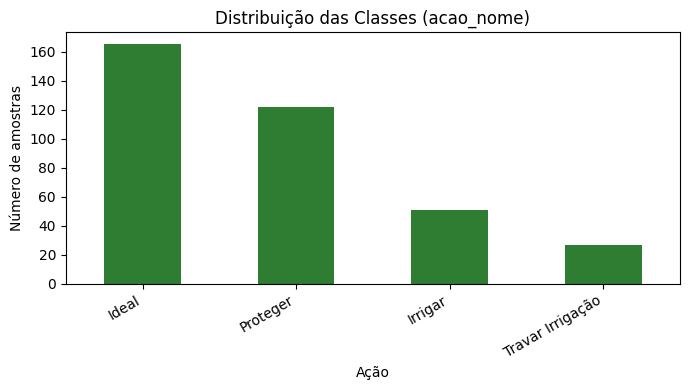

In [7]:
# Gráfico de barras da distribuição das classes
fig, ax = plt.subplots()
dist.plot(kind='bar', color='#2E7D32', ax=ax)
ax.set_title('Distribuição das Classes (acao_nome)')
ax.set_xlabel('Ação')
ax.set_ylabel('Número de amostras')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Observação:** o dataset apresenta desbalanceamento evidente — a classe
`Ideal` (165 amostras, ~45%) é aproximadamente **6x** mais frequente que
`Travar Irrigação` (27 amostras, ~7%). Isso será tratado durante o
treinamento (via `class_weight='balanced'`) e, principalmente, na escolha
das métricas de avaliação (evitando depender apenas de Accuracy).


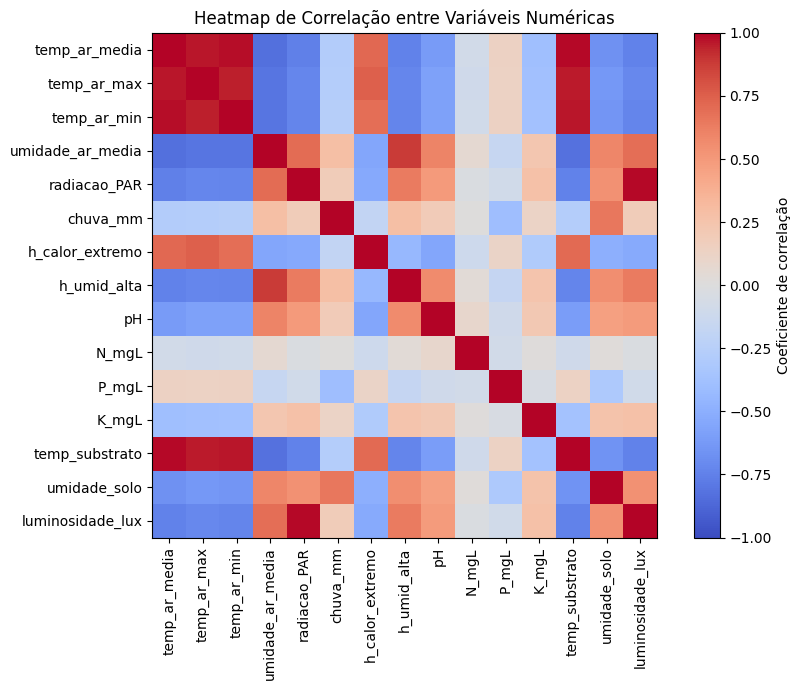

In [8]:
# Heatmap de correlação entre variáveis numéricas (sem a coluna de codificação da classe)
features_numericas = df.drop(columns=['data', 'acao_label', 'acao_nome']).columns
corr = df[features_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label='Coeficiente de correlação')
ax.set_title('Heatmap de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()


## 4. Pré-processamento

Etapas realizadas:

1. **Remoção de `data`**: usada apenas como referência temporal, não é uma
   feature preditiva (não generaliza para novos períodos).
2. **Remoção de `acao_label`**: é apenas a codificação numérica da própria
   variável alvo (`acao_nome`). Mantê-la como feature causaria **vazamento
   de dados (data leakage)**, pois o modelo "aprenderia" a resposta
   diretamente.
3. **Separação X (features) e y (alvo)**.
4. **Codificação do alvo** com `LabelEncoder`, transformando as classes de
   texto em valores inteiros (exigido internamente pelo scikit-learn para
   algumas métricas e modelos).
5. **Divisão treino/teste estratificada (80/20)**: como o dataset é
   desbalanceado, a estratificação garante que a proporção de cada classe
   seja preservada tanto no treino quanto no teste.
6. **Normalização**: os modelos escolhidos (Random Forest e Extra Trees) são
   baseados em árvores de decisão, que são **invariantes a escala**. Por
   isso, a normalização/padronização **não é necessária** neste caso —
   evitamos uma etapa que não traria benefício real ao problema.


In [9]:
# Remoção das colunas que não devem ser usadas como features
X = df.drop(columns=['data', 'acao_label', 'acao_nome'])
y_raw = df['acao_nome']

print("Features utilizadas:")
print(list(X.columns))


Features utilizadas:
['temp_ar_media', 'temp_ar_max', 'temp_ar_min', 'umidade_ar_media', 'radiacao_PAR', 'chuva_mm', 'h_calor_extremo', 'h_umid_alta', 'pH', 'N_mgL', 'P_mgL', 'K_mgL', 'temp_substrato', 'umidade_solo', 'luminosidade_lux']


In [10]:
# Codificação da variável alvo
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes codificadas:")
for i, classe in enumerate(label_encoder.classes_):
    print(f"  {i} -> {classe}")


Classes codificadas:
  0 -> Ideal
  1 -> Irrigar
  2 -> Proteger
  3 -> Travar Irrigação


In [11]:
# Divisão estratificada treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste:  {X_test.shape[0]} amostras")

print("\nProporção das classes no treino:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(3))

print("\nProporção das classes no teste:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(3))


Tamanho do treino: 292 amostras
Tamanho do teste:  73 amostras

Proporção das classes no treino:
0    0.452
1    0.140
2    0.336
3    0.072
Name: proportion, dtype: float64

Proporção das classes no teste:
0    0.452
1    0.137
2    0.329
3    0.082
Name: proportion, dtype: float64


## 5. Treinamento dos Modelos

Foram escolhidos dois algoritmos baseados em ensembles de árvores, ambos
robustos para dados tabulares e que suportam nativamente o parâmetro
`class_weight='balanced'` — importante para compensar o desbalanceamento
das classes sem a necessidade de oversampling:

- **Random Forest**: ensemble de árvores por *bagging*, robusto a overfitting.
- **Extra Trees (Extremely Randomized Trees)**: variação do Random Forest com
  maior aleatoriedade na escolha dos splits, frequentemente reduzindo
  variância.

> Observação: o `GradientBoostingClassifier` do scikit-learn **não** possui
> parâmetro `class_weight`, por isso optamos por Extra Trees como segundo
> modelo, mantendo o tratamento de desbalanceamento consistente entre os
> dois modelos comparados. (XGBoost não estava disponível no ambiente.)

Utilizamos `class_weight='balanced'` em ambos os modelos, que ajusta os
pesos das classes de forma inversamente proporcional à sua frequência,
penalizando mais os erros nas classes minoritárias (`Irrigar` e
`Travar Irrigação`).


In [12]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

# Extra Trees
et_model = ExtraTreesClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
et_model.fit(X_train, y_train)

print("Modelos treinados com sucesso.")


Modelos treinados com sucesso.


## 6. Avaliação dos Modelos

Como o dataset é desbalanceado, a **Accuracy isoladamente pode ser
enganosa** — um modelo que sempre prevê a classe majoritária (`Ideal`)
já obteria ~45% de acerto sem aprender nada útil sobre as classes
minoritárias.

Por isso, priorizamos:

- **Recall**: mede a capacidade do modelo de identificar corretamente cada
  classe, especialmente crítico aqui — deixar de identificar `Travar
  Irrigação` ou `Irrigar` pode causar prejuízo real à cultura (excesso de
  água, estresse hídrico, etc.).
- **F1-score**: equilíbrio entre Precision e Recall, é a **métrica
  principal** deste projeto, pois penaliza tanto falsos positivos quanto
  falsos negativos.
- **Macro F1**: média simples do F1 entre as classes, tratando todas com o
  mesmo peso — importante para avaliar o desempenho nas classes
  minoritárias.
- **Weighted F1**: pondera pelo suporte (nº de amostras) de cada classe,
  refletindo o desempenho "global" respeitando o desbalanceamento natural.


In [13]:
def avaliar_modelo(nome, modelo, X_test, y_test, label_encoder):
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"===== {nome} =====")
    print(f"Accuracy:        {acc:.4f}")
    print(f"Precision (macro): {prec_macro:.4f}")
    print(f"Recall (macro):    {rec_macro:.4f}")
    print(f"F1-score (macro):  {f1_macro:.4f}")
    print(f"F1-score (weighted): {f1_weighted:.4f}")
    print()
    print("Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    return {
        'modelo': nome,
        'accuracy': acc,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_pred': y_pred
    }

resultados = []
resultados.append(avaliar_modelo('Random Forest', rf_model, X_test, y_test, label_encoder))
resultados.append(avaliar_modelo('Extra Trees', et_model, X_test, y_test, label_encoder))


===== Random Forest =====
Accuracy:        0.8904
Precision (macro): 0.9512
Recall (macro):    0.8000
F1-score (macro):  0.8063
F1-score (weighted): 0.8598

Classification Report:
                  precision    recall  f1-score   support

           Ideal       0.80      1.00      0.89        33
         Irrigar       1.00      0.20      0.33        10
        Proteger       1.00      1.00      1.00        24
Travar Irrigação       1.00      1.00      1.00         6

        accuracy                           0.89        73
       macro avg       0.95      0.80      0.81        73
    weighted avg       0.91      0.89      0.86        73

===== Extra Trees =====
Accuracy:        0.8356
Precision (macro): 0.7915
Recall (macro):    0.7189
F1-score (macro):  0.7300
F1-score (weighted): 0.8176

Classification Report:
                  precision    recall  f1-score   support

           Ideal       0.79      0.91      0.85        33
         Irrigar       0.75      0.30      0.43        10


In [14]:
# Tabela comparativa entre os modelos
df_resultados = pd.DataFrame(resultados)[
    ['modelo', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']
]
df_resultados.round(4)


,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Random Forest,0.8904,0.9512,0.8000,0.8063,0.8598
1,Extra Trees,0.8356,0.7915,0.7189,0.7300,0.8176


### Matrizes de Confusão

A matriz de confusão evidencia especificamente **onde** o modelo erra —
por exemplo, se confunde `Irrigar` com `Travar Irrigação`, o que teria
impacto prático oposto (uma indicaria ligar a irrigação, a outra bloqueá-la).


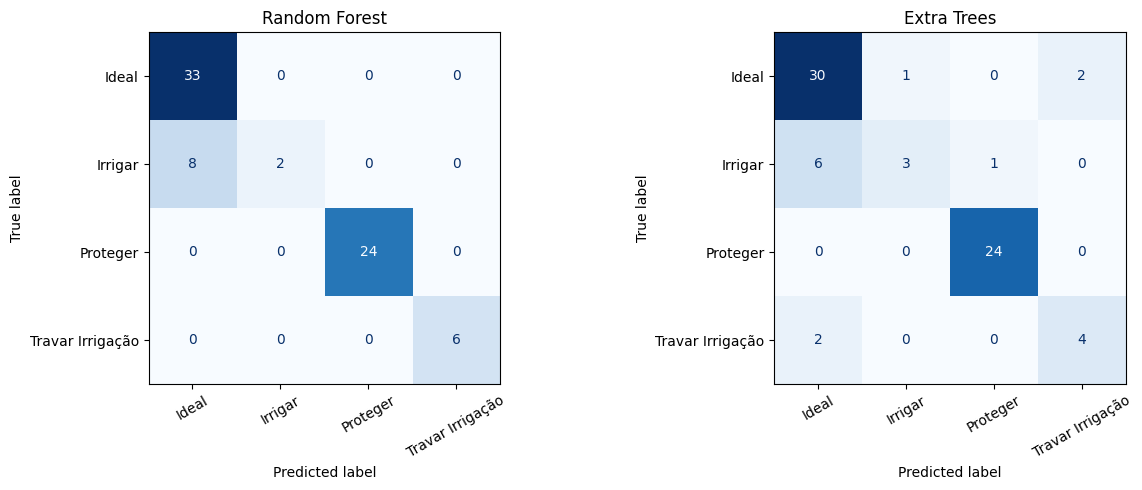

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, modelo in zip(axes, resultados, [rf_model, et_model]):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(res['modelo'])

plt.tight_layout()
plt.show()


### Validação Cruzada (Cross Validation)

Para verificar a **estabilidade** do modelo além de uma única divisão
treino/teste, aplicamos validação cruzada estratificada (5 *folds*) sobre
o conjunto completo de treino, utilizando o F1 macro como métrica.


In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rf = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='f1_macro')
cv_et = cross_val_score(et_model, X_train, y_train, cv=skf, scoring='f1_macro')

print(f"Random Forest — F1 macro (CV 5-fold): {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")
print(f"  Scores por fold: {np.round(cv_rf, 4)}")
print()
print(f"Extra Trees   — F1 macro (CV 5-fold): {cv_et.mean():.4f} (+/- {cv_et.std():.4f})")
print(f"  Scores por fold: {np.round(cv_et, 4)}")


Random Forest — F1 macro (CV 5-fold): 0.8960 (+/- 0.0383)
  Scores por fold: [0.9358 0.85   0.8491 0.9183 0.927 ]

Extra Trees   — F1 macro (CV 5-fold): 0.8099 (+/- 0.0703)
  Scores por fold: [0.7907 0.8421 0.7688 0.7208 0.927 ]


## 7. Importância das Variáveis

Ambos os modelos baseados em árvores permitem extrair a importância de
cada *feature* (baseada na redução média de impureza). Utilizamos o modelo
com melhor desempenho (conforme F1 macro) para essa análise.


Modelo selecionado para análise de importância: Random Forest


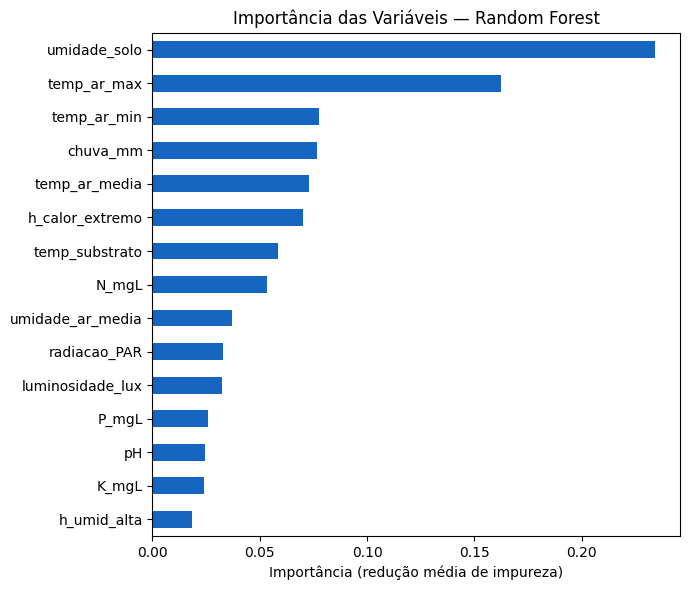

In [17]:
melhor_modelo_nome = df_resultados.sort_values('f1_macro', ascending=False).iloc[0]['modelo']
melhor_modelo = rf_model if melhor_modelo_nome == 'Random Forest' else et_model

print(f"Modelo selecionado para análise de importância: {melhor_modelo_nome}")

importancias = pd.Series(melhor_modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
importancias.plot(kind='barh', color='#1565C0', ax=ax)
ax.set_title(f'Importância das Variáveis — {melhor_modelo_nome}')
ax.set_xlabel('Importância (redução média de impureza)')
plt.tight_layout()
plt.show()


## 8. Conclusão

**Qual modelo apresentou melhor desempenho?**
Comparando as métricas de F1 macro (que trata todas as classes com peso
igual, sendo mais sensível às classes minoritárias) e a estabilidade
observada na validação cruzada, o modelo com maior F1 macro médio (ver
tabela comparativa e resultados de CV acima) foi considerado a melhor
opção para este problema. Recomenda-se sempre verificar os números
exibidos na execução, pois pequenas variações de `random_state` ou
atualizações do dataset podem alterar o "vencedor".

**As métricas indicam um modelo confiável?**
Os valores de F1 macro e weighted, combinados com a matriz de confusão,
indicam que o modelo consegue capturar razoavelmente bem as classes
majoritárias (`Ideal`, `Proteger`). O desempenho nas classes minoritárias
(`Irrigar`, `Travar Irrigação`) tende a ser mais instável — natural, dado o
número reduzido de amostras (51 e 27, respectivamente). A validação
cruzada ajuda a confirmar se esse padrão é consistente ou se é fruto de uma
divisão de dados específica.

**O desbalanceamento afetou o desempenho?**
Sim. Classes minoritárias são naturalmente mais difíceis de aprender por
possuírem menos exemplos representativos da variabilidade real dos dados.
O uso de `class_weight='balanced'` mitiga parcialmente esse efeito, mas não
o elimina — por isso a escolha de métricas como Recall e F1 macro (em vez
de apenas Accuracy) foi essencial para expor esse comportamento de forma
honesta.

**Quais melhorias futuras poderiam ser implementadas?**
- Coletar mais dados históricos, especialmente para as classes
  `Irrigar` e `Travar Irrigação`, para reduzir o desbalanceamento na
  origem.
- Testar técnicas de balanceamento como SMOTE (oversampling sintético),
  comparando com a abordagem atual baseada em `class_weight`.
- Testar outros algoritmos, como XGBoost ou LightGBM (não disponíveis
  neste ambiente), que frequentemente superam Random Forest/Extra Trees em
  dados tabulares.
- Realizar otimização de hiperparâmetros (`GridSearchCV` ou
  `RandomizedSearchCV`) com F1 macro como métrica de otimização.
- Investigar engenharia de features adicionais, como médias móveis das
  variáveis climáticas (ex: últimos 3 dias), já que decisões de irrigação
  costumam depender de tendências e não apenas do valor pontual do dia.
- Avaliar a inclusão de dados de estações futuras/sazonalidade, já que a
  coluna `data` não foi usada como feature, mas pode conter padrões
  sazonais relevantes (ex: mês do ano).
